# Predicting the Ocean Surface Boundary Layer's Density Profiles using Observational Data 



In this project, our group apply the same methodology from the paper *Sane et al. (2023) "Parameterizing vertical mixing coefficients in the ocean surface boundary layer using neural networks."*
to estimate density profiles using observational data from Papa Station (Located in the North Pacific Ocean, 50° North latitude, 145° West longitude) and analyze the effects of seasonality on the dataset.

### Tasks Addressed:
- **Data Processing and Preparation**: Acquire and clean data from Papa Station as well as reading and filtering the Generalized Ocean Turbulence Model (GOTM) output.
- **Identify the depths of the mixed layer**: Determine the mixed layer depths (MLD), h, from Papa Station Mooring data.
- **Neural Network Training**: Implementing neural networks to predict the density / diffusivity based on observational data as well as creating a NN which takes as inputs SST, SSS, time [0-365] to predict the density profile for the next timestep.
- **Model Evaluation and Visualization**: Evaluate the model's performance using metrics such as training and validation loss, and present the results visually.
- **Paper vs. observational data**: Examine the relationship between observational data variables and the input variables used in the paper.
- **Seasonality**: Explain the effects of seasonality on GOTM simulations vs. observational data

### Research Question: Apply the methodology from the paper to estimate density profiles from observational data and examine the influence of seasonality.

#### Import Modules and load files

In [1]:
# code
from utils import (
    load_cdf_files,
    plot_invalid_values,
    filter_valid_timesteps,
    merge_and_prepare_datasets,
    plot_variable_histograms,
    plot_dp_distributions,
    plot_correlation_heatmap,
    create_density_profile_filled,
    preprocess_train_valid_data,
    learnKappa_layers,
    modeltrain_loss,
    plot_training_validation_loss,
    plot_density_profile,
    performance_sigma_point,
    prepare_data_pipeline,
)
from pprint import pprint
import determine_mld

/Users/azamkhan/anaconda3/envs/nasa/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# code
dss = load_cdf_files("data")
print("List of observational variables from PAPA Mooring Station:\n")
pprint(list(dss.keys()))

List of observational variables from PAPA Mooring Station:

['temperature_profile',
 'longwave_radiation',
 'air_temperature',
 'possition_lon_lat',
 'shortwave_radiation',
 'sea_surface_salinity',
 'sea_surface_temperature',
 'barometric_pressure',
 'wind_speed_profile',
 'rain',
 'density_profile',
 'salinity_profile']


In [3]:
# code

# Data Processing and Preparation


## Data Quality Codes

The observational data is reported with different layers of quality:
- 0: **missing**
- 1: **highest**
- 2: **default**
- 3: **adjusted**
- 4: **lower**
- 5: **sensor failure**

We decided to accept points of "highest", "default" and "adjusted" quality. When columns were more than 3/4 missing, we fully omitted them. For columns with _some_ missing or poor quality data, we used stepwise interpolation to fill in the values.

Quality data for temperature (from _pyncview_):
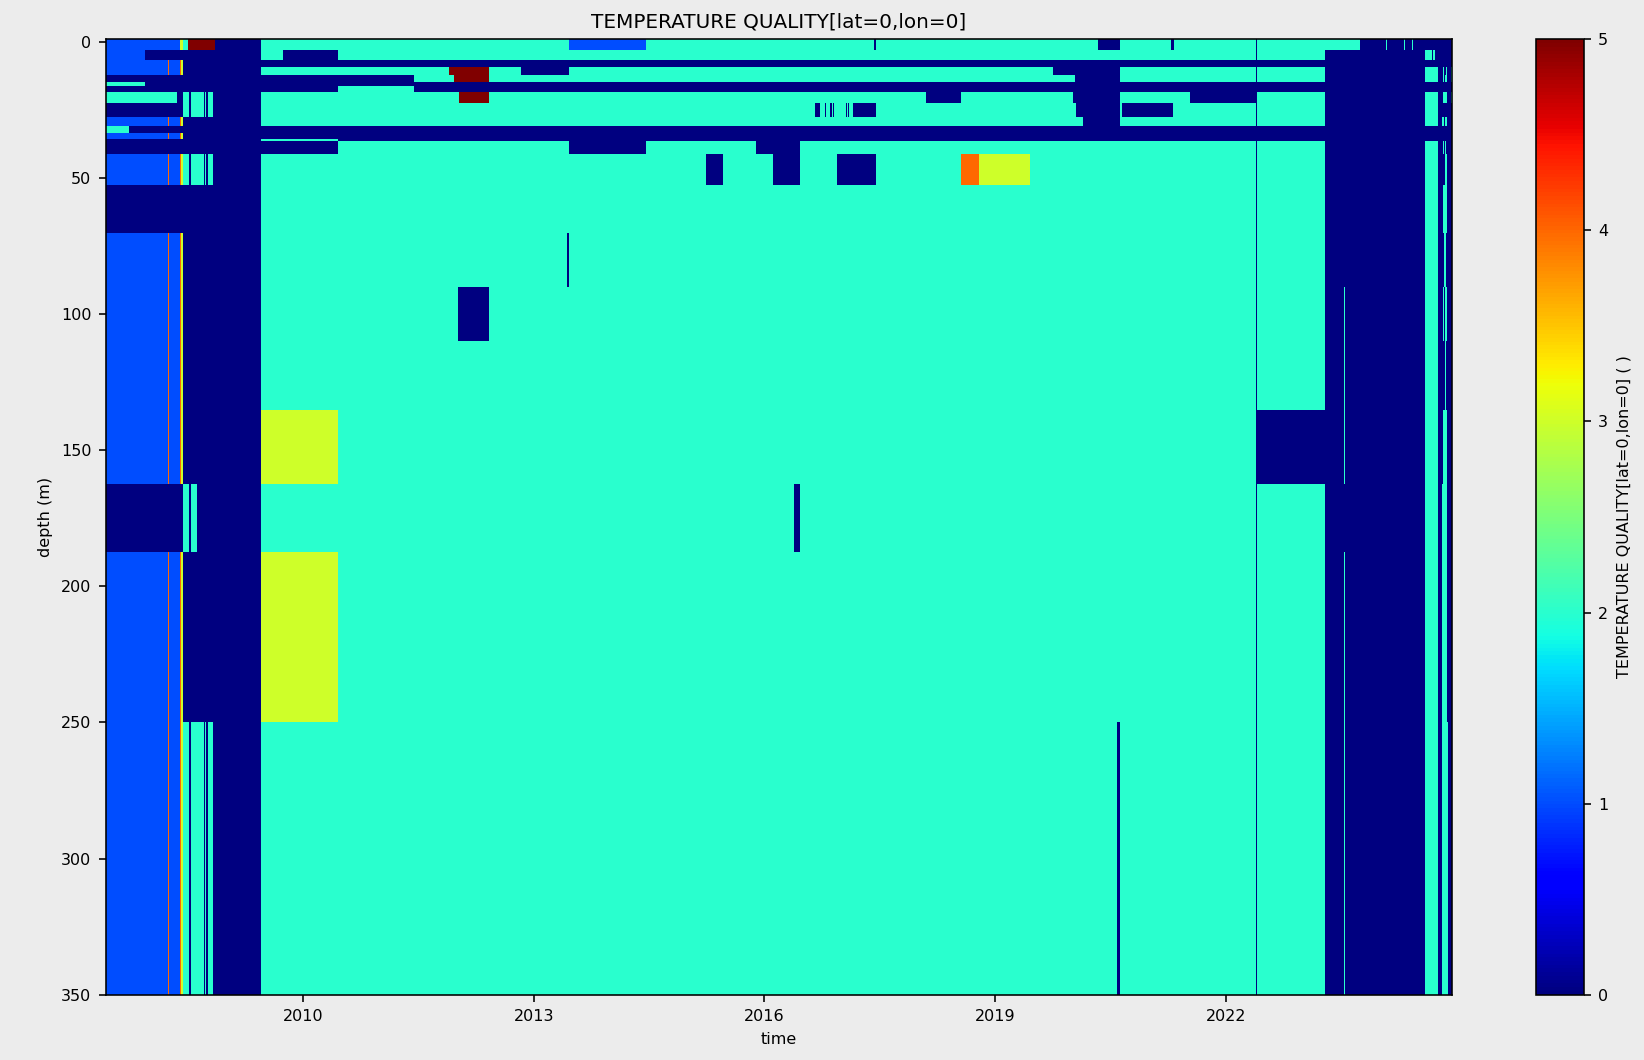

Quality data for density (from _pyncview_):
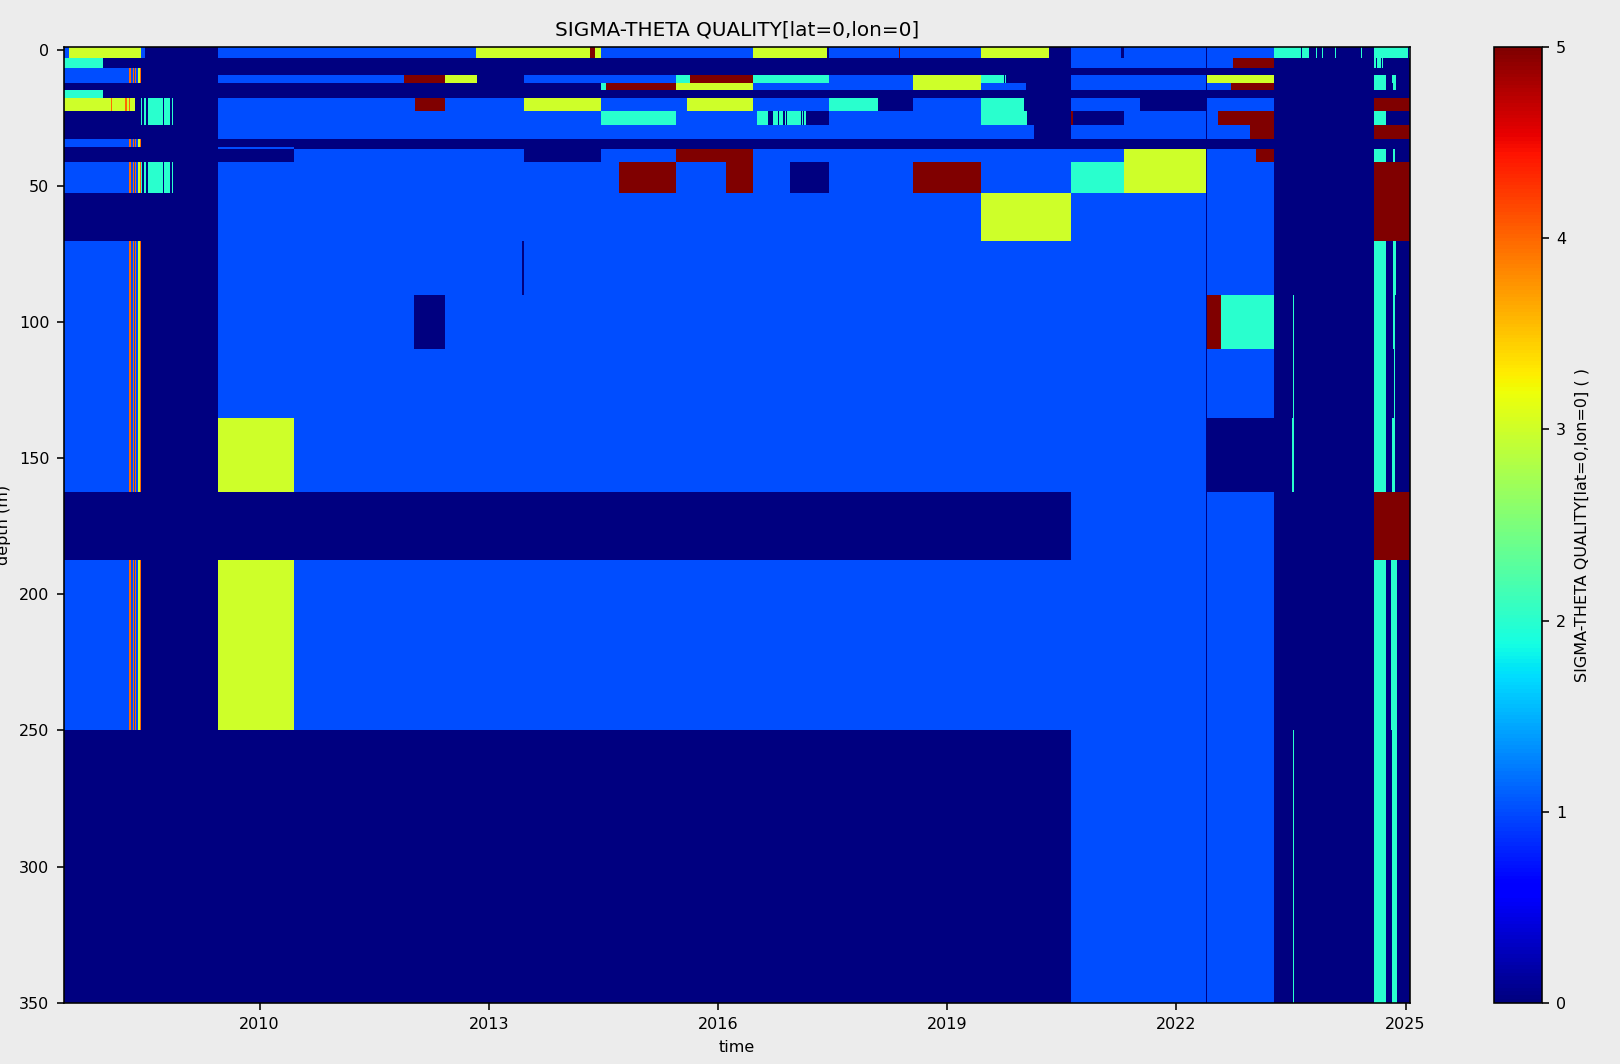

The density value is not measured directly, but is computed from temperature and ocean conductivity. You can see in these plots that quality issues in the temperature data are forwarded onto the density plot.



## Visualizing Cleaned Profiles and Mixed Layer Depth

Once cleaned, we can visualize the data. We wanted to show the Mixed Layer Depth (MLD) to understand how it changes over time. The mixed layer can be understood as a region of homogenous water, so we attempt to compute its boundary with thresholding.

$$ |\rho(z) - \rho_{surface}| > 0.03kg/m^3  $$
$$ |T(z) - T_{surface}| > 0.2C°  $$

**Graph 1** below depicts seasonal variations in temperature (ranging from yellow to purple) and mixed layer depth (shown in green) over time. During winter, temperatures are lower, and the mixed layer deepens, whereas in summer, temperatures rise, and the mixed layer becomes shallower. This graph is based on pure observetional data from Papa Station.

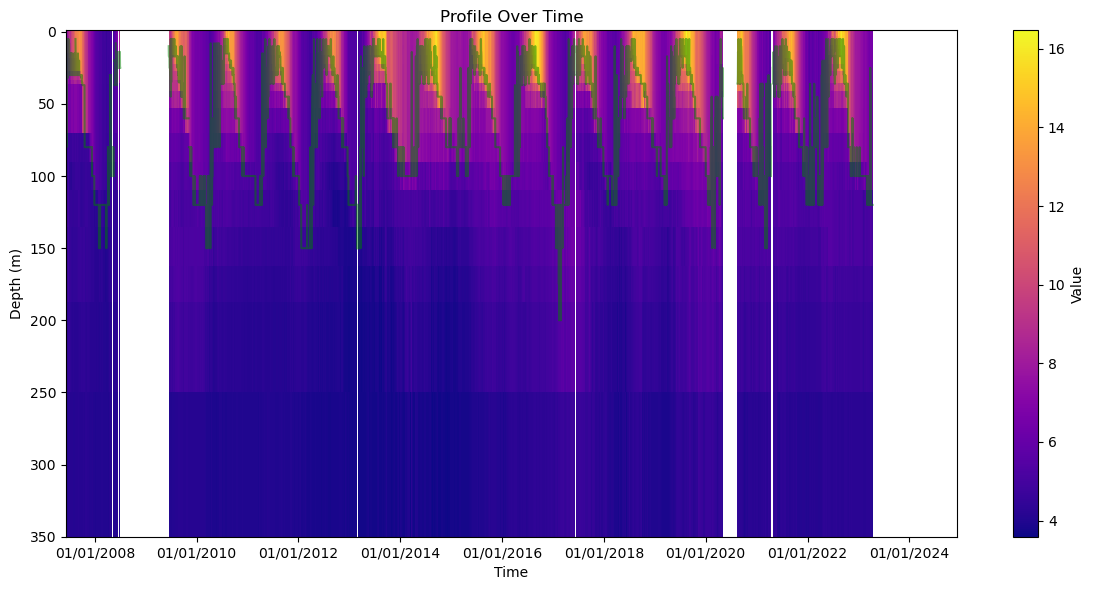

In [4]:
from determine_mld import plot_mld
_, temperature_based_mld = plot_mld('temperature_papa')


**Graph 2** below depicts seasonal variations in density.

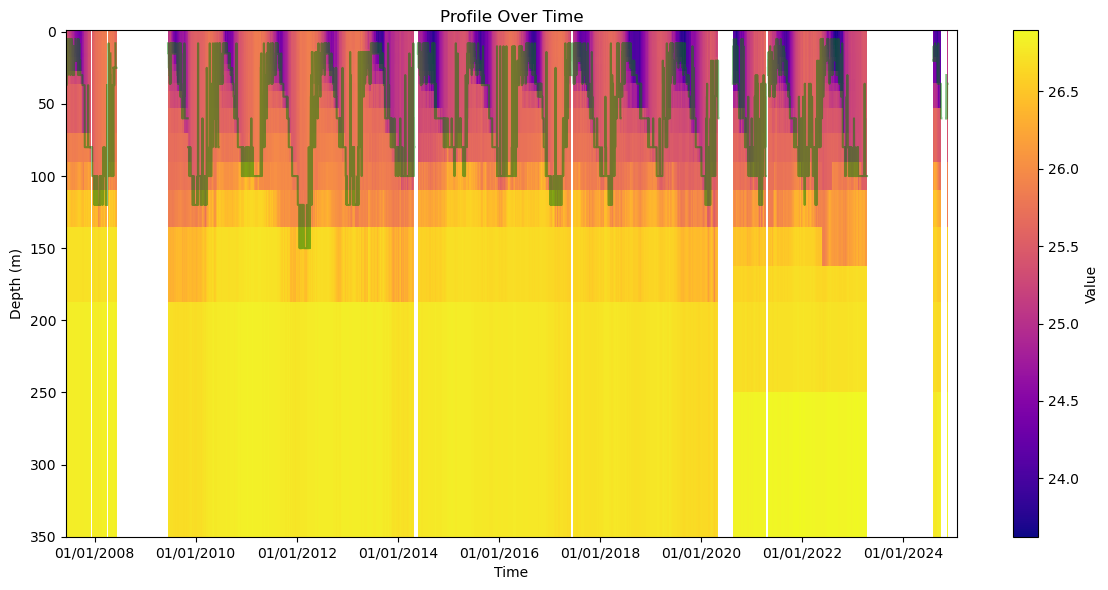

In [5]:
# code
_, density_based_mld = plot_mld('density_papa')

## Mixed Layer Depth Seasonality

Next, we compared the derived MLD values against each other and on a yearly basis. Additionally, we explored running our own GOTM simulation using meteorological forcing data from Papa station. The sim values seemed substantially higher than the the thresholded versions, so we ultimately discarded it.

In [8]:
# code
from determine_mld import plot_mld_comparison

# plot_mld_comparison(density_based_mld, temperature_based_mld)

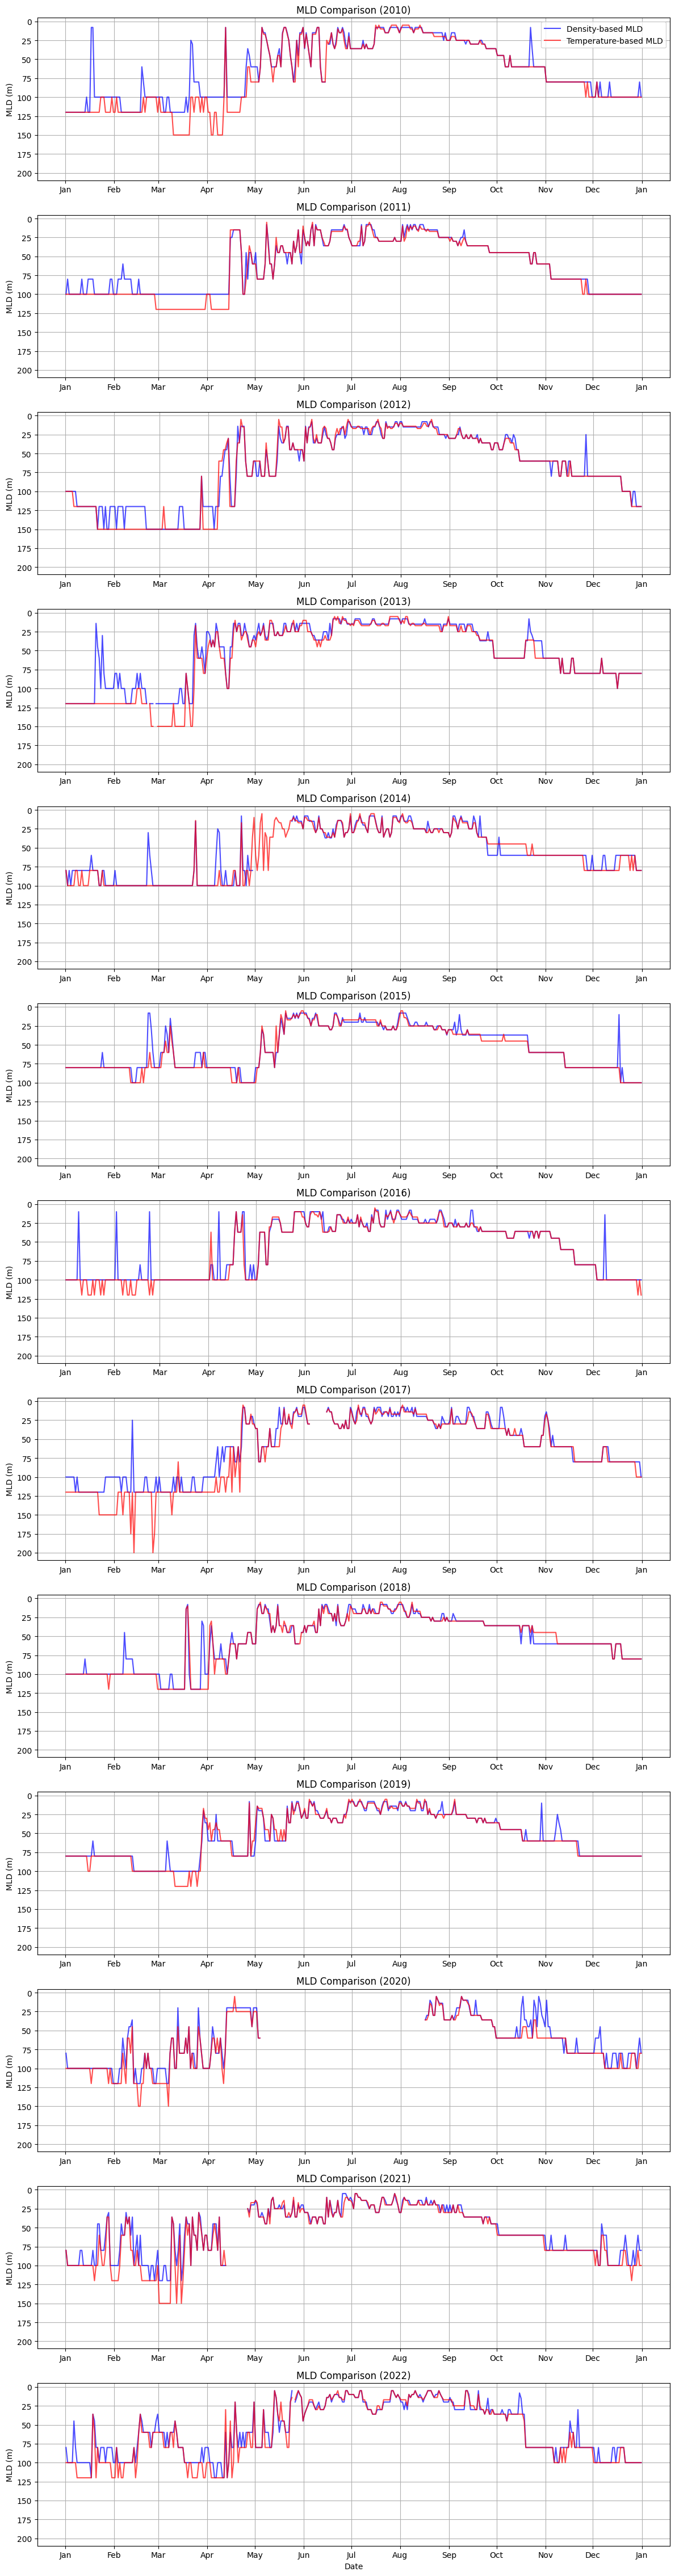

In [ ]:
# code
from determine_mld import plot_mld_comparison_by_year

plot_mld_comparison_by_year(density_based_mld, temperature_based_mld)

In [ ]:
# code
temp = filter_valid_timesteps(dss, "sea_surface_temperature", "QT_5025", "T_25")
sst = filter_valid_timesteps(dss, "sea_surface_salinity", "QS_5041", "S_41")
profiles, _ = determine_mld.plot_mld("density_papa")
filled_profiles = create_density_profile_filled(profiles, dss)

In [10]:
# code
full_df = merge_and_prepare_datasets(
    [(temp, ["time", "T_25"]), (sst, ["time", "S_41"])],
    filled_profiles,
    ["time"],
    ["time", "T_25", "S_41"],
)

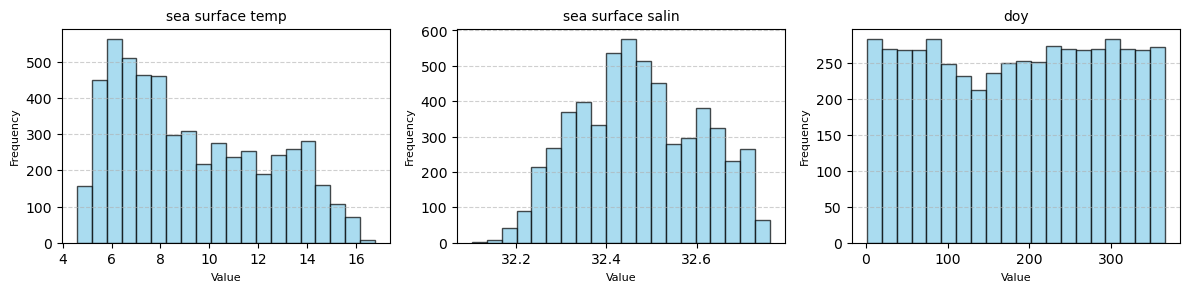

In [11]:
# code
variables = {
    "sea surface temp": temp.values.flatten(),
    "sea surface salin": sst.values.flatten(),
    "doy": full_df["doy"].values.flatten(),
}

plot_variable_histograms(variables)

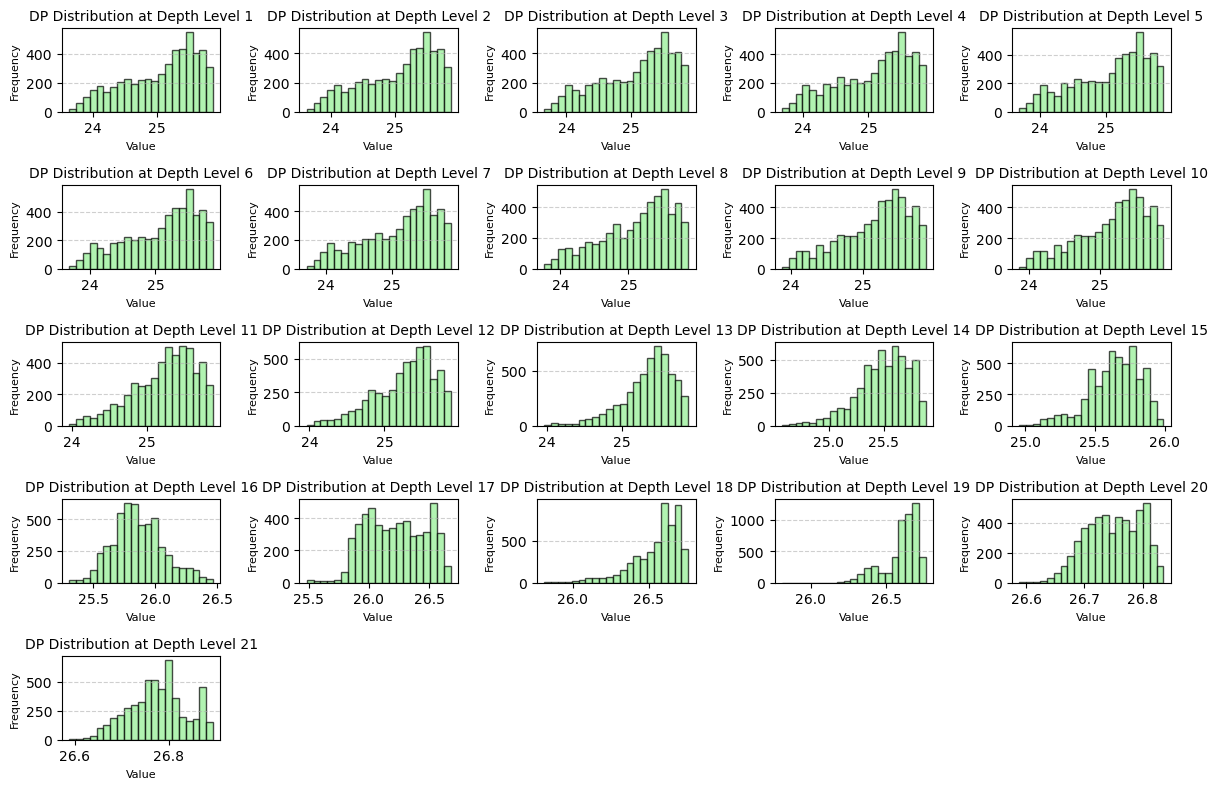

In [12]:
plot_dp_distributions(full_df)

- **Graph 3**: The plots processes and visualizes data from Papa Station for the variables wind speed, sea surface temperature, sea surface salinity, and day of the year (doy). The plots show the distribution of each variable's values, with bins representing the frequency of occurrences.

In [ ]:
# code

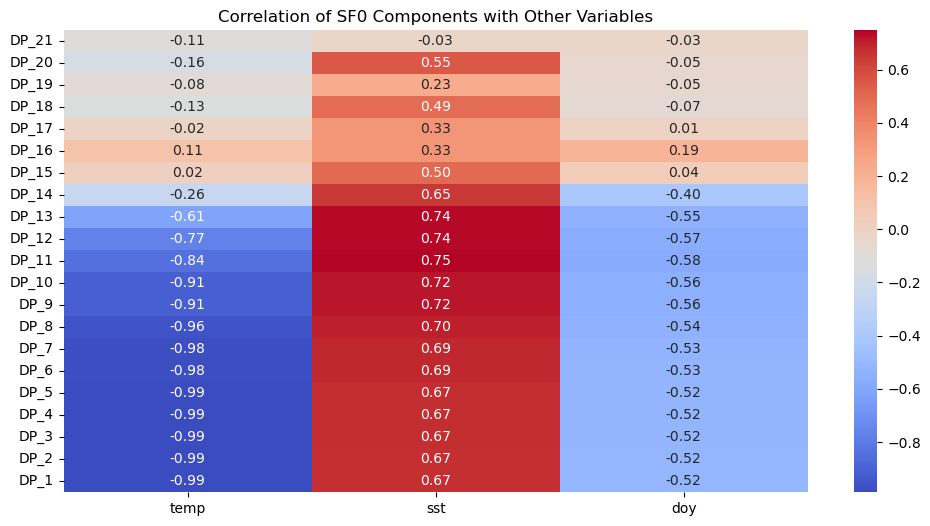

In [13]:
# code
data = {
    "temp": full_df["T_25"].values.flatten(),
    "sst": full_df["S_41"].values.flatten(),
    "doy": full_df["doy"].values.flatten(),
}

plot_correlation_heatmap(full_df, data)

- **Graph 4**:  A heatmap that visualizes the correlation between wind speed (ws), sea surface temperature (sst), temperature (temp), and day of year (doy), along with other environmental variables.

In [15]:
# code
import copy as copy

variables = [
    {"name": "T_25", "type": "static"},
    {"name": "S_41", "type": "static"},
    {"name": "doy", "type": "static"},
    {"name": "DP_21", "type": "dp"},  # Will use default DP config
]
data_load_main = prepare_data_pipeline(full_df, variables)
data_load3 = copy.deepcopy(data_load_main)

data, x, y, stats, k_mean, k_std, valid_x, valid_y, maxes = preprocess_train_valid_data(
    data_load3
)

In [16]:
# code
import torch
print("Training Set Size:", len(x))
print("Validation Set Size:", len(valid_x))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Convert to PyTorch tensors and move to device
x = torch.tensor(x, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)
valid_x = torch.tensor(valid_x, dtype=torch.float32).to(device)
valid_y = torch.tensor(valid_y, dtype=torch.float32).to(device)


Training Set Size: 4192
Validation Set Size: 1048


In [ ]:
# Train N1 for the first time!
epochs, k_points, lr = 5000, 21, 1e-02
in_nod, hid_nod, o_nod = 3, 32, 21

torch.manual_seed(10)

k_mean_c = torch.tensor(k_mean).float().to(device)
k_std_c = torch.tensor(k_std).float().to(device)

model = learnKappa_layers(in_nod, hid_nod, o_nod)
model = model.to(device)
model, loss_array = modeltrain_loss(in_nod,hid_nod,o_nod,lr,epochs,x,y,valid_x,valid_y,model,device,k_mean_c,k_std_c,patience=1000,
)


Training Progress:  29%|██▉       | 1445/5000 [00:08<00:22, 161.39epoch/s, patience_count=999, train_loss=0.00321, valid_loss=0.00608]


Early stopping at epoch 1445. Validation loss has not improved for 1000 epochs.


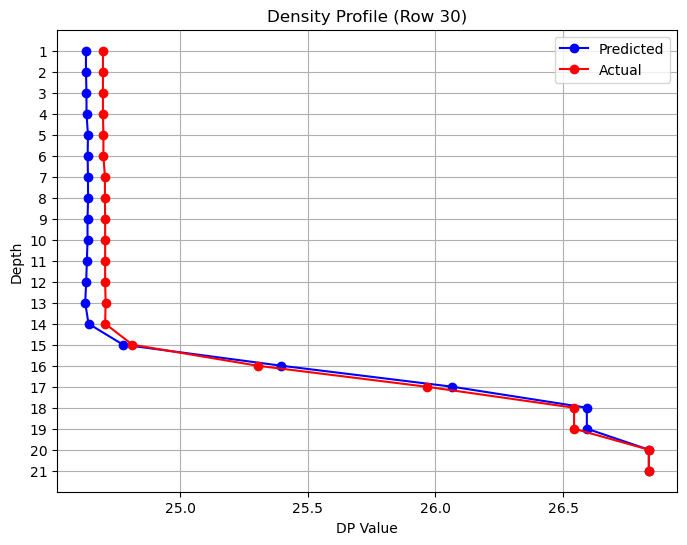

In [18]:
plot_density_profile(
    30,
    model(valid_x[30]).detach().numpy(),
    valid_y[30].detach().numpy(),
    k_std,
    k_mean,
    maxes,
)

- **Graph 5**: The graph was generated by using neural network training to predict the next density profile, based on temperature, salinity, and time. The plot shows the predicted vs. actual density profile (DP) values for a given depth in the dataset. The depth is shown on the y-axis (increasing depth downward). The DP values are plotted on the x-axis, with the predicted values in blue and the actual values in red. 

In [ ]:
# code

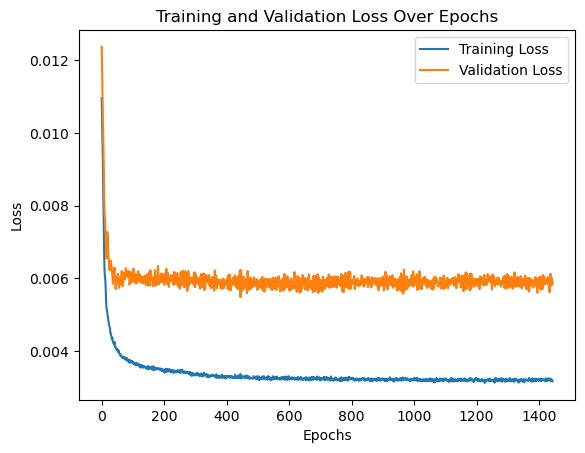

In [19]:
# code
plot_training_validation_loss(loss_array)

- **Graph 6**: The plot shows the training loss and validation loss over multiple epochs during the training of the NN model. The x-axis represents the number of epochs (iterations) during training while the y-axis represents the loss values, which measure the difference between the predicted output and the actual target for each example in the dataset.  

In [ ]:
# code

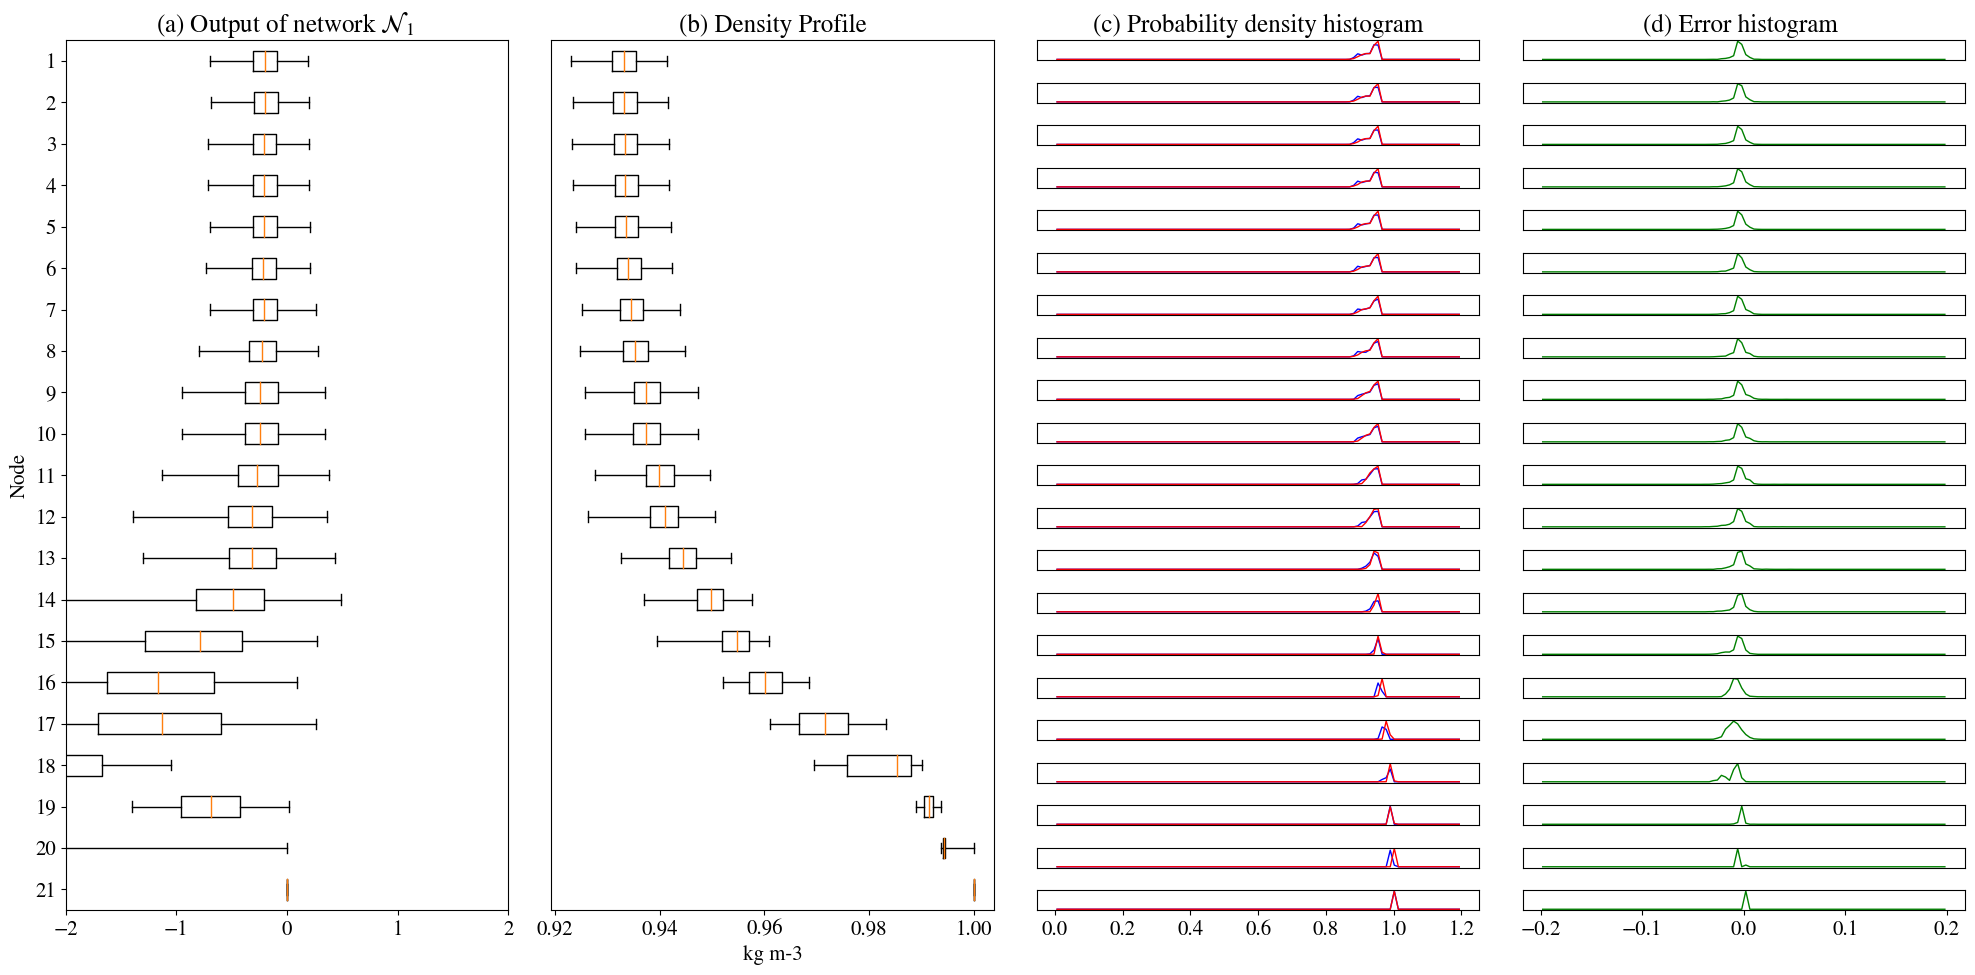

In [20]:
# code
performance_sigma_point(
    model,
    x,
    valid_x,
    y,
    valid_y,
    k_mean,
    k_std,
    maxes,
)

- **Graph 7**: The graphs visualize the performance of a neural network model by plotting output differences, density profiles, and probability and error histograms. From left to right- Network Output Differences show how the predicted and actual outputs differ for each node in the network. The Density Profile predicts the next density profile implementing neural networks which takes as inputs SST, SSS, time [0-365]. Probability Density Histograms show the distribution of the model's predictions compared to the actual values. Error Histograms show the distribution of the errors between the predicted and actual values.

In [ ]:
# code

In [ ]:
# code

## Seasonality 




The surface ocean is influenced by mechanical forces from wind stress and tidal interactions with the seafloor, thermal processes driven by solar radiation and heat exchange with the atmosphere, and freshwater fluxes resulting from interactions with the atmosphere, sea ice, or adjacent landmasses. Seasonal variations driven by these factors impact temperature and density, which in turn influence ocean stratification and mixing.

### Why seasonality is important (changes in the mixed layer depth):
- **Summer**: during summer, increased solar radiation warms the surface ocean, making the water less dense and more stratified. This leads to a thinner mixed layer as heating inhibits turbulence. Also, the density profile of the upper ocean is more stratified (stronger vertical gradient) in summer due to the warming of the surface layer.
- **Winter**: during winter, cooling temperatures and mechanical forcing from winds and storms deepen the mixed layer by increasing the density of surface waters, causing convection and mixing with deeper waters. The mixed layer is thickest at the end of winter due to accumulated cooling and storm activity. Also, in winter, the density profile becomes more uniform as surface cooling and wind-driven mixing deepen the mixed layer, reducing stratification.


In [ ]:
import pandas as pd

# Create the data as a dictionary
data = {
    "Season": ["Summer", "Fall", "Winter", "Spring"],
    "Temperature": ["High (SST warm)", "Cooling", "Coldest", "Warming"],
    "Density": ["Low (thermal expansion)", "Increasing", "Highest (cooling + brine rejection)", "Decreasing"],
    "Stratification": ["Strong", "Weakening", "Weak", "Strengthening"],
    "Mixed Layer Depth": ["Shallow ", "Deepening ", "Deepest ", "Shallowing "]}

# Convert dictionary to DataFrame
df = pd.DataFrame(data)

# Print the DataFrame
print(df.to_string(index=False))


Season     Temperature                             Density Stratification Mixed Layer Depth
Summer High (SST warm)             Low (thermal expansion)         Strong          Shallow 
  Fall         Cooling                          Increasing      Weakening        Deepening 
Winter         Coldest Highest (cooling + brine rejection)           Weak          Deepest 
Spring         Warming                          Decreasing  Strengthening       Shallowing 
